# Training Robust Neural Networks

First chapter from the **DataCamp** [Intermediate Deep Learning with PyTorch](https://campus.datacamp.com/courses/intermediate-deep-learning-with-pytorch) course.

In [ ]:
import importlib
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchmetrics import Accuracy
import scripts.dl_custom_classes as dlclasses

## 1 - PyTorch and OOP

* Object-oriented programming, OOP, is used throughout the PyTorch community to define objects with more flexibility.

* OOP to define PyTorch Datasets and models.

* We will be working with the water potability dataset storage in the data folder. The task is to classify a water sample as potable or drinkable (1 or 0) based on its chemical characteristics.

* Python classes will be store in the scripts folder and later import to the current notebook.

### 1.1 - Import training data

In [16]:
importlib.reload(dlclasses) # Reload changes for an external file

dataset_train = dlclasses.WaterDataset(
    path='/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/water_train.csv'
)

train_dataloader = DataLoader(
    dataset=dataset_train,
    batch_size=2,
    shuffle=True
)

dataset_train.df.head()

ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
0.483566,0.615597,0.513964,0.777394,0.354601,0.335319,0.367332,0.514102,0.617313,1
0.639608,0.516021,0.380558,0.39019,0.628308,0.157487,0.451506,0.55865,0.834925,0
0.370117,0.847246,0.623556,0.992911,0.145461,0.345829,0.334781,0.402932,0.590146,1
0.545159,0.261747,0.292037,0.535522,0.436155,0.7136,0.667406,0.47188,0.138483,0
0.610883,0.525235,0.465619,0.475133,0.634338,0.196409,0.623423,0.520589,0.755856,0


In [17]:
features, labels = next(iter(dataset_train))
print(f"Features: {features},\nLabels: {labels}")

Features: tensor([0.4836, 0.6156, 0.5140, 0.7774, 0.3546, 0.3353, 0.3673, 0.5141, 0.6173]),
Labels: 1.0


### 1.2 - Optimizers, Training and Evaluation

Training loop:

In [ ]:
net = dlclasses.Net()
criterion = nn.BCELoss() # Binary Cross-Entropy

# Stocastic Gradient Descend - SGD
# Adaptive Gradient -  Adagrad
# Root Mean Squere Propagation - RMSprop
# Adaptive Moment Estimation - Adam
optimizer = optim.Adam(net.parameters(), lr=0.01)

for epoch in range(10):
    for features, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = net(features)
        loss = criterion(outputs, labels.view(-1, 1))
        loss.backward()
        optimizer.step()

In [19]:
total = 0
for parameter in net.parameters():
    total += parameter.numel()
print(f'Model capacity = {total}')

Model capacity = 305


Evaluation loop:

In [21]:
dataset_test = dlclasses.WaterDataset(
    path='/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/water_test.csv'
)

test_dataloader = DataLoader(
    dataset=dataset_test,
    batch_size=2,
    shuffle=True
)

dataset_train.df.head()

ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
0.483566,0.615597,0.513964,0.777394,0.354601,0.335319,0.367332,0.514102,0.617313,1
0.639608,0.516021,0.380558,0.39019,0.628308,0.157487,0.451506,0.55865,0.834925,0
0.370117,0.847246,0.623556,0.992911,0.145461,0.345829,0.334781,0.402932,0.590146,1
0.545159,0.261747,0.292037,0.535522,0.436155,0.7136,0.667406,0.47188,0.138483,0
0.610883,0.525235,0.465619,0.475133,0.634338,0.196409,0.623423,0.520589,0.755856,0


In [22]:
acc = Accuracy(task='binary')

net.eval()
with torch.no_grad():
    for features, labels in test_dataloader:
        outputs = net(features)
        preds = (outputs >= 0.5).float()
        acc(preds, labels.view(-1, 1))

accuracy = acc.compute()
print(f'Accuracy: {accuracy}')

Accuracy: 0.5904572606086731


## 2 - Vanishing and Exploding Gradients

* Gradient instability during training. Sometimes, the gradients get smaller during the backward pass, this is known as vanishing gradients. In other hand, sometimes gradients get bigger and bigger (parameter updates are to large and training diverges), this is known as exploding gradients

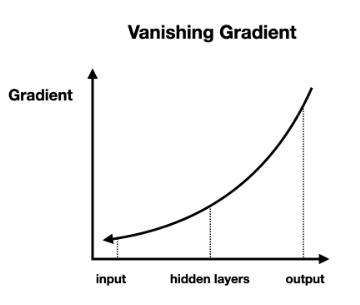

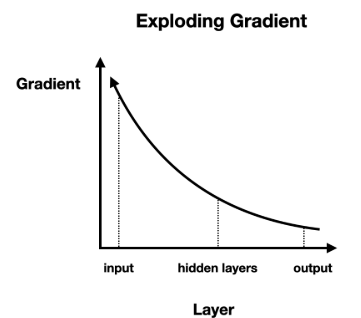

Solution to unstable gradientes:

* 1) Proper weights initialization

For ReLu and similar, we can use He/Kaiming initialization

* 2) Good activations

ReLu (Rectified Liner Unit) is arguably the most commonly used activation. Zero for negative inputs: during training, some neuron only output a zero, if inputs to a neuron become negative, it dies.

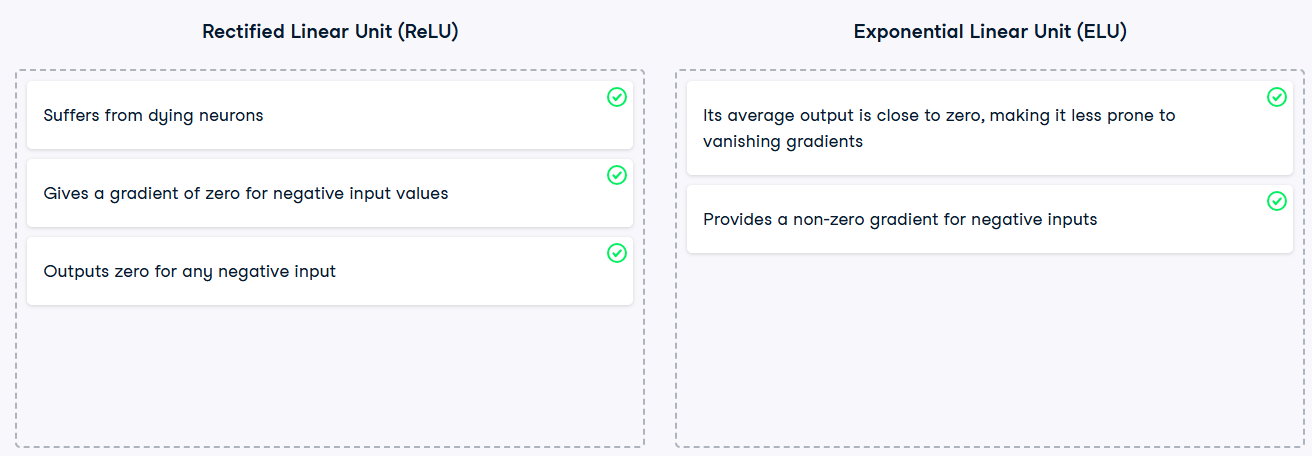

Alternatively use ELU (Exponential Linear Unit) to improve upon ReLu.

* 3) Batch normalization

Batch normalization is an operation applied after a layer, in which the layer's outputs are first normalized by subtracting the mean and dividing by the standard deviation. This ensures the output distribution is roughly normal.